## BIXI

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import folium
from IPython.display import display
import geopandas as gpd
from shapely.geometry import Point
from shapely.geometry import mapping
from shapely.ops import transform
from folium.plugins import HeatMap
from folium.features import GeoJson, GeoJsonTooltip
from folium import Element
import pyproj
import networkx as nx
import branca
from branca.colormap import linear
import osmnx as ox
from shapely.ops import nearest_points
from itertools import combinations
import pyproj
from shapely.geometry import LineString
from math import comb
import unicodedata
from math import radians, sin, cos, asin, sqrt
from branca.colormap import LinearColormap
import calendar

# BIXI reading Files_Temporal Sparse  

In [ ]:
file_path = "DonneesOuvertes2025_01020304050607080910.csv"
df = pd.read_csv(file_path)


In [26]:
df.head()

,STARTSTATIONNAME,STARTSTATIONARRONDISSEMENT,STARTSTATIONLATITUDE,STARTSTATIONLONGITUDE,ENDSTATIONNAME,ENDSTATIONARRONDISSEMENT,ENDSTATIONLATITUDE,ENDSTATIONLONGITUDE,STARTTIMEMS,ENDTIMEMS
0,Fullum / Marie-Anne,Le Plateau-Mont-Royal,45.536505,-73.568039,Boyer / du Mont-Royal,Le Plateau-Mont-Royal,45.527432,-73.579917,1745255625940,1.745256e+12
1,de Normanville / Everett,Villeray—Saint-Michel—Parc-Extension,45.545433,-73.614385,Marquette / du Mont-Royal (sud),Le Plateau-Mont-Royal,45.532077,-73.575143,1745242787194,1.745244e+12
2,Prince-Arthur / Ste-Famille,Le Plateau-Mont-Royal,45.511670,-73.574635,Duluth / St-Denis,Le Plateau-Mont-Royal,45.520628,-73.575949,1745244099726,1.745244e+12
3,du Canal / McLaughlin,Lachine,45.429692,-73.669488,St-Patrick / Thomas-Keefer,Le Sud-Ouest,45.478012,-73.574273,1745254311560,1.745257e+12
4,de l'Hôtel-de-Ville / Villeneuve,Le Plateau-Mont-Royal,45.523481,-73.587328,Marmier / St-Denis,Rosemont - La Petite-Patrie,45.530805,-73.598396,1745255560449,1.745256e+12


In [27]:
### column check + name cleaning + parse START/END time

# --- 1) Basic column sanity check ---
print("Columns in raw df:\n", df.columns.tolist())

# --- 2) Helper: clean station names consistently ---
def clean_station_name(s: pd.Series) -> pd.Series:
    return (
        s.astype(str)
         .str.replace("\u00a0", " ", regex=False)   # non-breaking space
         .str.strip()
         .str.replace(r"\s+", " ", regex=True)      # collapse multiple spaces
    )

# --- 3) Apply cleaning on names (start & end) ---
df["START_NAME_CLEAN"] = clean_station_name(df["STARTSTATIONNAME"])
df["END_NAME_CLEAN"]   = clean_station_name(df["ENDSTATIONNAME"])

print("\nExample cleaned station names (start):")
print(df[["STARTSTATIONNAME","START_NAME_CLEAN"]].head(5))

# --- 4) Parse STARTTIMEMS into datetime ---
# Your file shows STARTTIMEMS like 1704230756167 (looks like ms since epoch).
# Detect seconds vs milliseconds safely for each timestamp column.
def parse_epoch_to_dt(x: pd.Series, colname: str) -> pd.Series:
    ts = pd.to_numeric(x, errors="coerce")
    med = ts.dropna().median()
    unit = "ms" if med > 1e11 else "s"
    dt = pd.to_datetime(ts, unit=unit, errors="coerce")
    print(f"Parsed {colname} using unit='{unit}'.")
    return dt

df["start_dt"] = parse_epoch_to_dt(df["STARTTIMEMS"], "STARTTIMEMS")
df["end_dt"]   = parse_epoch_to_dt(df["ENDTIMEMS"],   "ENDTIMEMS")    ###### DEFINE THIS !!!!!!!!

print("\nTime parsing preview:")
print(df[["STARTTIMEMS","start_dt","ENDTIMEMS","end_dt"]].head(5))


# Optional: drop rows with invalid START time or missing station names
# (Keep rows even if end_dt is missing; we’ll naturally drop NaN end_dt only where needed.)


before = len(df)
df = df.dropna(subset=["start_dt", "START_NAME_CLEAN", "END_NAME_CLEAN"])
print(f"\nDropped {before - len(df)} rows with missing time or station names.")
print("Remaining rows:", len(df))


Columns in raw df:
 ['STARTSTATIONNAME', 'STARTSTATIONARRONDISSEMENT', 'STARTSTATIONLATITUDE', 'STARTSTATIONLONGITUDE', 'ENDSTATIONNAME', 'ENDSTATIONARRONDISSEMENT', 'ENDSTATIONLATITUDE', 'ENDSTATIONLONGITUDE', 'STARTTIMEMS', 'ENDTIMEMS']

Example cleaned station names (start):
                   STARTSTATIONNAME                  START_NAME_CLEAN
0               Fullum / Marie-Anne               Fullum / Marie-Anne
1          de Normanville / Everett          de Normanville / Everett
2       Prince-Arthur / Ste-Famille       Prince-Arthur / Ste-Famille
3             du Canal / McLaughlin             du Canal / McLaughlin
4  de l'Hôtel-de-Ville / Villeneuve  de l'Hôtel-de-Ville / Villeneuve
Parsed STARTTIMEMS using unit='ms'.
Parsed ENDTIMEMS using unit='ms'.

Time parsing preview:
     STARTTIMEMS                start_dt     ENDTIMEMS                  end_dt
0  1745255625940 2025-04-21 17:13:45.940  1.745256e+12 2025-04-21 17:20:19.881
1  1745242787194 2025-04-21 13:39:47.194  1.745244

In [28]:
df.head()



,STARTSTATIONNAME,STARTSTATIONARRONDISSEMENT,STARTSTATIONLATITUDE,STARTSTATIONLONGITUDE,ENDSTATIONNAME,ENDSTATIONARRONDISSEMENT,ENDSTATIONLATITUDE,ENDSTATIONLONGITUDE,STARTTIMEMS,ENDTIMEMS,START_NAME_CLEAN,END_NAME_CLEAN,start_dt,end_dt
0,Fullum / Marie-Anne,Le Plateau-Mont-Royal,45.536505,-73.568039,Boyer / du Mont-Royal,Le Plateau-Mont-Royal,45.527432,-73.579917,1745255625940,1.745256e+12,Fullum / Marie-Anne,Boyer / du Mont-Royal,2025-04-21 17:13:45.940,2025-04-21 17:20:19.881
1,de Normanville / Everett,Villeray—Saint-Michel—Parc-Extension,45.545433,-73.614385,Marquette / du Mont-Royal (sud),Le Plateau-Mont-Royal,45.532077,-73.575143,1745242787194,1.745244e+12,de Normanville / Everett,Marquette / du Mont-Royal (sud),2025-04-21 13:39:47.194,2025-04-21 14:01:06.223
2,Prince-Arthur / Ste-Famille,Le Plateau-Mont-Royal,45.511670,-73.574635,Duluth / St-Denis,Le Plateau-Mont-Royal,45.520628,-73.575949,1745244099726,1.745244e+12,Prince-Arthur / Ste-Famille,Duluth / St-Denis,2025-04-21 14:01:39.726,2025-04-21 14:07:34.098
3,du Canal / McLaughlin,Lachine,45.429692,-73.669488,St-Patrick / Thomas-Keefer,Le Sud-Ouest,45.478012,-73.574273,1745254311560,1.745257e+12,du Canal / McLaughlin,St-Patrick / Thomas-Keefer,2025-04-21 16:51:51.560,2025-04-21 17:32:07.153
4,de l'Hôtel-de-Ville / Villeneuve,Le Plateau-Mont-Royal,45.523481,-73.587328,Marmier / St-Denis,Rosemont - La Petite-Patrie,45.530805,-73.598396,1745255560449,1.745256e+12,de l'Hôtel-de-Ville / Villeneuve,Marmier / St-Denis,2025-04-21 17:12:40.449,2025-04-21 17:20:30.051


In [29]:
print(df.columns)

Index(['STARTSTATIONNAME', 'STARTSTATIONARRONDISSEMENT',
       'STARTSTATIONLATITUDE', 'STARTSTATIONLONGITUDE', 'ENDSTATIONNAME',
       'ENDSTATIONARRONDISSEMENT', 'ENDSTATIONLATITUDE', 'ENDSTATIONLONGITUDE',
       'STARTTIMEMS', 'ENDTIMEMS', 'START_NAME_CLEAN', 'END_NAME_CLEAN',
       'start_dt', 'end_dt'],
      dtype='object')


In [30]:
# --- Canonical coords from START ---
### compute one lat/lon per station name, using the most frequent coordinate (mode)
###  for both start and end, then combine

start_coord_mode = (
    df.groupby("START_NAME_CLEAN")[["STARTSTATIONLATITUDE","STARTSTATIONLONGITUDE"]]
      .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
      .reset_index()
      .rename(columns={
          "START_NAME_CLEAN":"Station_Name",
          "STARTSTATIONLATITUDE":"Latitude",
          "STARTSTATIONLONGITUDE":"Longitude"
      })
)

# --- Canonical coords from END ---
end_coord_mode = (
    df.groupby("END_NAME_CLEAN")[["ENDSTATIONLATITUDE","ENDSTATIONLONGITUDE"]]
      .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
      .reset_index()
      .rename(columns={
          "END_NAME_CLEAN":"Station_Name",
          "ENDSTATIONLATITUDE":"Latitude",
          "ENDSTATIONLONGITUDE":"Longitude"
      })
)

# Combine and keep one row per station (prefer start coords if both exist)
stations_coords = (
    pd.concat([start_coord_mode, end_coord_mode], ignore_index=True)
      .dropna(subset=["Latitude","Longitude"])
      .drop_duplicates(subset=["Station_Name"], keep="first")
      .reset_index(drop=True)
)

print("stations_coords shape:", stations_coords.shape)
print(stations_coords.head(10))


stations_coords shape: (1270, 3)
                 Station_Name   Latitude  Longitude
0         10e Avenue / Masson  45.550394 -73.573762
1  10e Avenue Nord / King Est  45.408466 -71.872624
2     12e avenue / St-Zotique  45.556867 -73.589306
3     14e avenue / Jean-Talon  45.561324 -73.596294
4             15e Rue / Robin  45.559377 -73.698510
5      15e avenue / Dandurand  45.554787 -73.574259
6        15e avenue / Laurier  45.553320 -73.569328
7      16e avenue / St-Joseph  45.552936 -73.565771
8     19e avenue / St-Zotique  45.561683 -73.585648
9    1ere avenue / St-Zotique  45.551880 -73.593591


In [31]:
# --- Station-level totals (all trips in dataset period) ---
### Station totals: departures, arrivals, total, net


dep = df["START_NAME_CLEAN"].value_counts().rename("Trips_out")
arr = df["END_NAME_CLEAN"].value_counts().rename("Trips_in")

stations_counts = (
    pd.concat([dep, arr], axis=1)
      .fillna(0)
      .astype(int)
      .reset_index()
      .rename(columns={"index":"Station_Name"})
)

stations_counts["Trips_total"] = stations_counts["Trips_out"] + stations_counts["Trips_in"]
stations_counts["Net_flow"]    = stations_counts["Trips_in"] - stations_counts["Trips_out"]

stations_clean = stations_coords.merge(stations_counts, on="Station_Name", how="left").fillna(0)

print("stations_clean shape:", stations_clean.shape)
print(stations_clean.head(10))

print("\nTop 10 by Trips_out (departures):")
print(stations_clean.sort_values("Trips_out", ascending=False)[["Station_Name","Trips_out","Trips_in","Trips_total"]].head(10))

print("\nTop 10 by Trips_total (departures+arrivals):")
print(stations_clean.sort_values("Trips_total", ascending=False)[["Station_Name","Trips_out","Trips_in","Trips_total"]].head(10))




stations_clean shape: (1270, 7)
                 Station_Name   Latitude  Longitude  Trips_out  Trips_in  \
0         10e Avenue / Masson  45.550394 -73.573762      10017      9688   
1  10e Avenue Nord / King Est  45.408466 -71.872624        470       437   
2     12e avenue / St-Zotique  45.556867 -73.589306       8297      7937   
3     14e avenue / Jean-Talon  45.561324 -73.596294       9305      9196   
4             15e Rue / Robin  45.559377 -73.698510       1702      1774   
5      15e avenue / Dandurand  45.554787 -73.574259      11503     11098   
6        15e avenue / Laurier  45.553320 -73.569328      14912     14385   
7      16e avenue / St-Joseph  45.552936 -73.565771      11367     10987   
8     19e avenue / St-Zotique  45.561683 -73.585648      10548     10308   
9    1ere avenue / St-Zotique  45.551880 -73.593591       2540      2554   

   Trips_total  Net_flow  
0        19705      -329  
1          907       -33  
2        16234      -360  
3        18501      -10

In [32]:
# --- Total number of unique stations (after cleaning + canonical coords) ---
n_stations = stations_clean["Station_Name"].nunique()
print("Total unique stations (cleaned):", n_stations)

# Optional quick checks
print("\nStations_clean columns:", stations_clean.columns.tolist())
print("\nAny duplicate Station_Name rows?",
      stations_clean["Station_Name"].duplicated().sum())

print("Total unique stations with canonical coordinates:", stations_coords["Station_Name"].nunique())


print("\nTop 5 stations by total activity:")
print(stations_clean.sort_values("Trips_total", ascending=False)[
    ["Station_Name", "Trips_out", "Trips_in", "Trips_total", "Net_flow", "Latitude", "Longitude"]
].head(5))



Total unique stations (cleaned): 1270

Stations_clean columns: ['Station_Name', 'Latitude', 'Longitude', 'Trips_out', 'Trips_in', 'Trips_total', 'Net_flow']

Any duplicate Station_Name rows? 0
Total unique stations with canonical coordinates: 1270

Top 5 stations by total activity:
                                        Station_Name  Trips_out  Trips_in  \
607   Métro Mont-Royal (Utilités publiques / Rivard)     128674    110790   
1238                           du Mont-Royal / Clark     111572     98186   
442                               Laurier / St-Denis      87886     68271   
444                             Laurier / de Brébeuf      69544     69164   
1215                           des Pins / St-Laurent      67395     62765   

      Trips_total  Net_flow   Latitude  Longitude  
607        239464    -17884  45.524353 -73.581432  
1238       209758    -13386  45.519410 -73.586850  
442        156157    -19615  45.527154 -73.589439  
444        138708      -380  45.532588 -73.584

In [33]:
print("START time coverage:")
print("  min start_dt:", df["start_dt"].min())
print("  max start_dt:", df["start_dt"].max())

print("\nEND time coverage:")
print("  min end_dt:", df["end_dt"].min())
print("  max end_dt:", df["end_dt"].max())

# print("\nUnique years (start):", sorted(df["year"].dropna().unique()))
# print("Unique months (start):", sorted(df["month"].dropna().unique()))


START time coverage:
  min start_dt: 2025-01-01 05:05:26.015000
  max start_dt: 2025-11-01 03:59:46.496000

END time coverage:
  min end_dt: 2025-01-01 05:08:28.725000
  max end_dt: 2025-11-12 11:34:36.610000


In [34]:
# --- Time features ---
## Add time features (date, month, week, hour)
#### 0 = Monday 


# Start-based features (for departures)
df["date"]  = df["start_dt"].dt.date
df["month"] = df["start_dt"].dt.month
df["year"]  = df["start_dt"].dt.year

iso = df["start_dt"].dt.isocalendar()
df["iso_year"] = iso["year"].astype(int)
df["iso_week"] = iso["week"].astype(int)

df["hour"] = df["start_dt"].dt.hour
df["dow"]  = df["start_dt"].dt.dayofweek  # 0=Mon ... 6=Sun

# End-based features (for arrivals)  ✅ FIX
df["end_date"]  = df["end_dt"].dt.date
df["end_month"] = df["end_dt"].dt.month
df["end_year"]  = df["end_dt"].dt.year

end_iso = df["end_dt"].dt.isocalendar()
df["end_iso_year"] = end_iso["year"].astype("Int64")  # keeps NaN safely
df["end_iso_week"] = end_iso["week"].astype("Int64")

df["end_hour"] = df["end_dt"].dt.hour
df["end_dow"]  = df["end_dt"].dt.dayofweek

print(df[["start_dt","date","month","iso_year","iso_week","hour","dow",
          "end_dt","end_date","end_month","end_year","end_iso_year","end_iso_week","end_hour","end_dow"]].head(10))


                 start_dt        date  month  iso_year  iso_week  hour  dow  \
0 2025-04-21 17:13:45.940  2025-04-21      4      2025        17    17    0   
1 2025-04-21 13:39:47.194  2025-04-21      4      2025        17    13    0   
2 2025-04-21 14:01:39.726  2025-04-21      4      2025        17    14    0   
3 2025-04-21 16:51:51.560  2025-04-21      4      2025        17    16    0   
4 2025-04-21 17:12:40.449  2025-04-21      4      2025        17    17    0   
5 2025-04-21 16:36:01.741  2025-04-21      4      2025        17    16    0   
6 2025-04-21 15:19:48.260  2025-04-21      4      2025        17    15    0   
7 2025-04-21 16:50:32.478  2025-04-21      4      2025        17    16    0   
8 2025-04-21 16:52:15.449  2025-04-21      4      2025        17    16    0   
9 2025-04-21 16:14:33.759  2025-04-21      4      2025        17    16    0   

                   end_dt    end_date  end_month  end_year  end_iso_year  \
0 2025-04-21 17:20:19.881  2025-04-21        4.0    20

In [35]:
print(df[["start_dt", "iso_year", "iso_week", "dow"]].head(10))
print("\nDOW mapping: 0=Mon ... 6=Sun")


                 start_dt  iso_year  iso_week  dow
0 2025-04-21 17:13:45.940      2025        17    0
1 2025-04-21 13:39:47.194      2025        17    0
2 2025-04-21 14:01:39.726      2025        17    0
3 2025-04-21 16:51:51.560      2025        17    0
4 2025-04-21 17:12:40.449      2025        17    0
5 2025-04-21 16:36:01.741      2025        17    0
6 2025-04-21 15:19:48.260      2025        17    0
7 2025-04-21 16:50:32.478      2025        17    0
8 2025-04-21 16:52:15.449      2025        17    0
9 2025-04-21 16:14:33.759      2025        17    0

DOW mapping: 0=Mon ... 6=Sun


In [36]:
# --- Total trips over time (system level) ---
### System-level totals by month / week / day / hour


daily_total   = df.groupby("date").size().rename("trips").reset_index()
monthly_total = df.groupby(["year","month"]).size().rename("trips").reset_index()
weekly_total  = df.groupby(["iso_year","iso_week"]).size().rename("trips").reset_index()
hourly_total  = df.groupby("hour").size().rename("trips").reset_index().sort_values("hour")

print("Daily total head:")
print(daily_total.head())

print("\nMonthly total head:")
print(monthly_total.head())

print("\nWeekly total head:")
print(weekly_total.head())

print("\nHourly total head (hour-of-day profile):")
print(hourly_total.head(24))


Daily total head:
         date  trips
0  2025-01-01   1755
1  2025-01-02   1883
2  2025-01-03   2361
3  2025-01-04   1703
4  2025-01-05   1409

Monthly total head:
   year  month    trips
0  2025      1    73146
1  2025      2    44120
2  2025      3   126410
3  2025      4   713179
4  2025      5  1608879

Weekly total head:
   iso_year  iso_week  trips
0      2025         1   9111
1      2025         2  15777
2      2025         3  19381
3      2025         4  17104
4      2025         5  14798

Hourly total head (hour-of-day profile):
    hour    trips
0      0   741996
1      1   623276
2      2   507022
3      3   387379
4      4   251109
5      5   159598
6      6   101259
7      7    79726
8      8    42364
9      9    66473
10    10   164922
11    11   428335
12    12   750068
13    13   529412
14    14   496002
15    15   591898
16    16   710212
17    17   721196
18    18   737864
19    19   866840
20    20  1108725
21    21  1324580
22    22  1121212
23    23   901668


In [37]:
############# CORRECT !!!!!

# --- Monthly per station ---
### Station-level monthly / weekly / daily totals (departures & arrivals)

# Departures by START time bins
monthly_out = df.groupby(["START_NAME_CLEAN","year","month"]).size().rename("Trips_out").reset_index()

# Arrivals by END time bins //////// FIXXXXXXXXXXXXXXX
monthly_in  = (
    df.dropna(subset=["end_dt"])
      .groupby(["END_NAME_CLEAN","end_year","end_month"]).size()
      .rename("Trips_in").reset_index()
      .rename(columns={"end_year":"year", "end_month":"month"})
)

monthly_in  = monthly_in.rename(columns={"END_NAME_CLEAN":"Station_Name"})
monthly_out = monthly_out.rename(columns={"START_NAME_CLEAN":"Station_Name"})

station_monthly = (
    monthly_out.merge(monthly_in, on=["Station_Name","year","month"], how="outer")
               .fillna(0)
)
station_monthly["Trips_total"] = station_monthly["Trips_out"] + station_monthly["Trips_in"]
station_monthly["Net_flow"]    = station_monthly["Trips_in"] - station_monthly["Trips_out"]

print("station_monthly head:")
print(station_monthly.head())

print("\nTop 5 stations by Trips_out (MONTHLY total across all months):")
print(
    station_monthly.groupby("Station_Name")["Trips_out"].sum()
                  .sort_values(ascending=False)
                  .head(5)
)

# Top 5 stations by PEAK monthly Trips_out (with corresponding month/year)
idx_peak = station_monthly.groupby("Station_Name")["Trips_out"].idxmax()

station_peak_month = (
    station_monthly.loc[idx_peak, ["Station_Name", "year", "month", "Trips_out"]]
    .rename(columns={"Trips_out": "PeakMonthlyTrips_out"})
    .sort_values("PeakMonthlyTrips_out", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 5 stations by PEAK monthly Trips_out (with corresponding month/year):")
print(station_peak_month.head(5))


# --- Weekly per station ---
# Departures by START ISO week bins
weekly_out = df.groupby(["START_NAME_CLEAN","iso_year","iso_week"]).size().rename("Trips_out").reset_index()

# Arrivals by END ISO week bins ✅ FIX
weekly_in  = (
    df.dropna(subset=["end_dt"])
      .groupby(["END_NAME_CLEAN","end_iso_year","end_iso_week"]).size()
      .rename("Trips_in").reset_index()
      .rename(columns={"end_iso_year":"iso_year", "end_iso_week":"iso_week"})
)

weekly_out = weekly_out.rename(columns={"START_NAME_CLEAN":"Station_Name"})
weekly_in  = weekly_in.rename(columns={"END_NAME_CLEAN":"Station_Name"})

station_weekly = (
    weekly_out.merge(weekly_in, on=["Station_Name","iso_year","iso_week"], how="outer")
              .fillna(0)
)
station_weekly["Trips_total"] = station_weekly["Trips_out"] + station_weekly["Trips_in"]

print("\nstation_weekly head:")
print(station_weekly.head())


# --- Daily per station ---
# Departures by START date
daily_out = df.groupby(["START_NAME_CLEAN","date"]).size().rename("Trips_out").reset_index()

# Arrivals by END date ✅ FIX
daily_in  = (
    df.dropna(subset=["end_dt"])
      .groupby(["END_NAME_CLEAN","end_date"]).size()
      .rename("Trips_in").reset_index()
      .rename(columns={"end_date":"date"})
)

daily_out = daily_out.rename(columns={"START_NAME_CLEAN":"Station_Name"})
daily_in  = daily_in.rename(columns={"END_NAME_CLEAN":"Station_Name"})

station_daily = (
    daily_out.merge(daily_in, on=["Station_Name","date"], how="outer")
             .fillna(0)
)
station_daily["Trips_total"] = station_daily["Trips_out"] + station_daily["Trips_in"]

print("\nstation_daily head:")
print(station_daily.head())


station_monthly head:
          Station_Name    year  month  Trips_out  Trips_in  Trips_total  \
0  10e Avenue / Masson  2025.0    7.0      523.0     517.0       1040.0   
1  10e Avenue / Masson  2025.0    8.0     3246.0    3137.0       6383.0   
2  10e Avenue / Masson  2025.0    9.0     3322.0    3218.0       6540.0   
3  10e Avenue / Masson  2025.0   10.0     2918.0    2811.0       5729.0   
4  10e Avenue / Masson  2025.0   11.0        8.0       5.0         13.0   

   Net_flow  
0      -6.0  
1    -109.0  
2    -104.0  
3    -107.0  
4      -3.0  

Top 5 stations by Trips_out (MONTHLY total across all months):
Station_Name
Métro Mont-Royal (Utilités publiques / Rivard)    128674.0
du Mont-Royal / Clark                             111572.0
Laurier / St-Denis                                 87886.0
Laurier / de Brébeuf                               69544.0
des Pins / St-Laurent                              67395.0
Name: Trips_out, dtype: float64

Top 5 stations by PEAK monthly Trips_o

In [38]:
# --- Overall hour-of-day profile by direction ---
#### Hourly-per-day (hour-of-day profile) overall + per station (for peaks)

hod_out = df.groupby("hour").size().rename("Trips_out").reindex(range(24), fill_value=0)

hod_in  = (
    df.dropna(subset=["end_dt"])
      .groupby("end_hour").size()
      .rename("Trips_in")
      .reindex(range(24), fill_value=0)
)

hod_total = (
    pd.concat([hod_out, hod_in], axis=1)
      .fillna(0)
      .astype(int)
      .reset_index()
      .rename(columns={"index":"hour"})
)
hod_total["Trips_total"] = hod_total["Trips_out"] + hod_total["Trips_in"]

print("Overall hour-of-day profile (0..23):")
print(hod_total.head(24))


# --- Per station hour-of-day profile ---
station_hod_out = (
    df.groupby(["START_NAME_CLEAN","hour"]).size()
      .rename("Trips_out").reset_index()
      .rename(columns={"START_NAME_CLEAN":"Station_Name"})
)

station_hod_in = (
    df.dropna(subset=["end_dt"])
      .groupby(["END_NAME_CLEAN","end_hour"]).size()
      .rename("Trips_in").reset_index()
      .rename(columns={"END_NAME_CLEAN":"Station_Name", "end_hour":"hour"})
)

station_hod = (
    station_hod_out.merge(station_hod_in, on=["Station_Name","hour"], how="outer")
                   .fillna(0)
)
station_hod["Trips_total"] = station_hod["Trips_out"] + station_hod["Trips_in"]

print("\nstation_hod head:")
print(station_hod.head())

# --- Peak hour per station (by total) ---
peak_by_station = (
    station_hod.sort_values(["Station_Name","Trips_total"], ascending=[True, False])
               .groupby("Station_Name")
               .head(1)
               .reset_index(drop=True)
               .sort_values("Trips_total", ascending=False)
)

print("\nTop 10 stations by peak-hour total activity:")
print(peak_by_station[["Station_Name","hour","Trips_out","Trips_in","Trips_total"]].head(10))


Overall hour-of-day profile (0..23):
    hour  Trips_out  Trips_in  Trips_total
0      0     741996    770196      1512192
1      1     623276    648117      1271393
2      2     507022    530130      1037152
3      3     387379    424144       811523
4      4     251109    277657       528766
5      5     159598    174549       334147
6      6     101259    111535       212794
7      7      79726     86150       165876
8      8      42364     48386        90750
9      9      66473     58167       124640
10    10     164922    142070       306992
11    11     428335    347394       775729
12    12     750068    729135      1479203
13    13     529412    562731      1092143
14    14     496002    483861       979863
15    15     591898    556588      1148486
16    16     710212    689537      1399749
17    17     721196    715230      1436426
18    18     737864    721370      1459234
19    19     866840    828243      1695083
20    20    1108725   1044955      2153680
21    21    13245

In [39]:
# Compare totals from station_monthly vs full-period stations_counts
check_out = station_monthly.groupby("Station_Name")["Trips_out"].sum()
check_in  = station_monthly.groupby("Station_Name")["Trips_in"].sum()

# Full period totals from stations_clean
base_out = stations_clean.set_index("Station_Name")["Trips_out"]
base_in  = stations_clean.set_index("Station_Name")["Trips_in"]

# Align indices
cmp = pd.DataFrame({
    "monthly_sum_out": check_out,
    "base_out": base_out,
    "monthly_sum_in": check_in,
    "base_in": base_in
}).fillna(0)

cmp["diff_out"] = cmp["monthly_sum_out"] - cmp["base_out"]
cmp["diff_in"]  = cmp["monthly_sum_in"]  - cmp["base_in"]

print("Max abs diff Trips_out:", cmp["diff_out"].abs().max())
print("Max abs diff Trips_in :", cmp["diff_in"].abs().max())
print("\nIf both are 0 (or extremely close), your aggregation is perfectly consistent.")


Max abs diff Trips_out: 0.0
Max abs diff Trips_in : 1.0

If both are 0 (or extremely close), your aggregation is perfectly consistent.


In [40]:
missing_end_count = df["end_dt"].isna().sum()
print("Trips with missing end_dt:", missing_end_count)
print("Share missing:", missing_end_count / len(df))


Trips with missing end_dt: 47999
Share missing: 0.003578506920380141


In [41]:
# --- TOP 40 stations by PEAK MONTHLY Trips_out ---
# Peak month row per station
idx_peak_m = station_monthly.groupby("Station_Name")["Trips_out"].idxmax()
peak_month_all = station_monthly.loc[idx_peak_m, ["Station_Name","year","month","Trips_out","Trips_in","Net_flow"]].copy()

# Rank by peak monthly Trips_out
top40_peak_month = (
    peak_month_all.sort_values("Trips_out", ascending=False)
                  .head(40)
                  .rename(columns={"Trips_out":"PeakMonthlyTrips_out",
                                   "Trips_in":"Trips_in_at_peak_month",
                                   "Net_flow":"Net_flow_at_peak_month"})
)

# Add coordinates
top40_peak_month = top40_peak_month.merge(
    stations_clean[["Station_Name","Latitude","Longitude"]],
    on="Station_Name",
    how="left"
)

# Nice ordering
top40_peak_month = top40_peak_month[[
    "Station_Name","year","month",
    "PeakMonthlyTrips_out","Trips_in_at_peak_month","Net_flow_at_peak_month",
    "Latitude","Longitude"
]].reset_index(drop=True)

print(top40_peak_month.head(30))


                                         Station_Name    year  month  \
0      Métro Mont-Royal (Utilités publiques / Rivard)  2025.0    8.0   
1                               du Mont-Royal / Clark  2025.0    9.0   
2                                  Laurier / St-Denis  2025.0    9.0   
3                                Laurier / de Brébeuf  2025.0    8.0   
4                             Prince-Arthur / du Parc  2025.0    9.0   
5                              Chabot / du Mont-Royal  2025.0    8.0   
6               de la Commune / Place Jacques-Cartier  2025.0    7.0   
7                               des Pins / St-Laurent  2025.0    6.0   
8                               McTavish / Sherbrooke  2025.0    9.0   
9                               Clark / Prince-Arthur  2025.0    6.0   
10               Parc Jean-Drapeau (Chemin MacDonald)  2025.0    8.0   
11              Métro Peel (de Maisonneuve / Stanley)  2025.0    8.0   
12                                    Clark / Laurier  2025.0   

In [42]:
# --- TOP 40 stations by PEAK DAILY Trips_out ---
idx_peak_d = station_daily.groupby("Station_Name")["Trips_out"].idxmax()
peak_day_all = station_daily.loc[idx_peak_d, ["Station_Name","date","Trips_out","Trips_in"]].copy()
peak_day_all["Net_flow"] = peak_day_all["Trips_in"] - peak_day_all["Trips_out"]

top40_peak_day = (
    peak_day_all.sort_values("Trips_out", ascending=False)
                .head(40)
                .rename(columns={"Trips_out":"PeakDailyTrips_out",
                                 "Trips_in":"Trips_in_at_peak_day",
                                 "Net_flow":"Net_flow_at_peak_day"})
)

top40_peak_day = top40_peak_day.merge(
    stations_clean[["Station_Name","Latitude","Longitude"]],
    on="Station_Name",
    how="left"
)

top40_peak_day = top40_peak_day[[
    "Station_Name","date",
    "PeakDailyTrips_out","Trips_in_at_peak_day","Net_flow_at_peak_day",
    "Latitude","Longitude"
]].reset_index(drop=True)

print(top40_peak_day.head(10))


                                     Station_Name        date  \
0  Métro Mont-Royal (Utilités publiques / Rivard)  2025-08-07   
1                           du Mont-Royal / Clark  2025-06-14   
2                          Jean Langlois / Fullum  2025-07-25   
3                     de l'Esplanade / Marie-Anne  2025-09-14   
4            Parc Jean-Drapeau (Chemin MacDonald)  2025-08-02   
5                            Laurier / de Brébeuf  2025-08-09   
6                          Jean-Langlois / Fullum  2025-08-01   
7                              Laurier / St-Denis  2025-06-11   
8                       Sherbrooke / Jeanne-d'Arc  2025-09-21   
9         Métro Atwater (Atwater / Ste-Catherine)  2025-06-11   

   PeakDailyTrips_out  Trips_in_at_peak_day  Net_flow_at_peak_day   Latitude  \
0               903.0                 715.0                -188.0  45.524353   
1               761.0                 708.0                 -53.0  45.519410   
2               708.0                 925.0 

In [43]:
# --- Station × date × hour table (needed to extract date for the peak hour) ---

# Departures by start date + start hour
st_date_hour_out = (
    df.groupby(["START_NAME_CLEAN", "date", "hour"]).size()
      .rename("Trips_out").reset_index()
      .rename(columns={"START_NAME_CLEAN":"Station_Name"})
)

# Arrivals by end date + end hour
st_date_hour_in = (
    df.dropna(subset=["end_dt"])
      .groupby(["END_NAME_CLEAN", "end_date", "end_hour"]).size()
      .rename("Trips_in").reset_index()
      .rename(columns={"END_NAME_CLEAN":"Station_Name", "end_date":"date", "end_hour":"hour"})
)

station_date_hour = (
    st_date_hour_out.merge(st_date_hour_in, on=["Station_Name","date","hour"], how="outer")
                    .fillna(0)
)

station_date_hour["Trips_total"] = station_date_hour["Trips_out"] + station_date_hour["Trips_in"]
station_date_hour["Net_flow"]    = station_date_hour["Trips_in"] - station_date_hour["Trips_out"]

print(station_date_hour.head())


          Station_Name        date  hour  Trips_out  Trips_in  Trips_total  \
0  10e Avenue / Masson  2025-07-24  16.0        1.0       1.0          2.0   
1  10e Avenue / Masson  2025-07-24  17.0        2.0       3.0          5.0   
2  10e Avenue / Masson  2025-07-24  18.0        1.0       2.0          3.0   
3  10e Avenue / Masson  2025-07-24  19.0        2.0       1.0          3.0   
4  10e Avenue / Masson  2025-07-24  20.0        1.0       1.0          2.0   

   Net_flow  
0       0.0  
1       1.0  
2       1.0  
3      -1.0  
4       0.0  


In [44]:
# --- For each station: pick the (date,hour) row with MAX Trips_out ---
# If ties exist, we choose the earliest date among tied maxima.

# Sort so that within each station, max Trips_out comes first, and earliest date breaks ties
station_date_hour_sorted = station_date_hour.sort_values(
    ["Station_Name", "Trips_out", "date", "hour"],
    ascending=[True, False, True, True]
)

peak_row_per_station = (
    station_date_hour_sorted.groupby("Station_Name", as_index=False).head(1)
)

# # Now select TOP 40 stations by that peak Trips_out
# top40_peak_hour_with_date = (
#     peak_row_per_station.sort_values("Trips_out", ascending=False)
#                         .head(40)
#                         .rename(columns={
#                             "Trips_out":"PeakHourlyTrips_out",
#                             "Trips_in":"Trips_in_at_peak_hour",
#                             "Net_flow":"Net_flow_at_peak_hour"
#                         })
#                         .merge(stations_clean[["Station_Name","Latitude","Longitude"]],
#                                on="Station_Name", how="left")
#                         .reset_index(drop=True)
# )

top40_peak_hour_with_date = (
    peak_row_per_station
        .sort_values("Trips_out", ascending=False)
        .head(40)
        .rename(columns={
            "Trips_out": "PeakHourlyTrips_out",
            "Trips_in": "Trips_in_at_peak_hour",
            "Net_flow": "Net_flow_at_peak_hour"
        })
        .merge(
            stations_clean[["Station_Name", "Latitude", "Longitude"]],
            on="Station_Name",
            how="left"
        )
        .reset_index(drop=True)
)


# Reorder columns for clarity
top40_peak_hour_with_date = top40_peak_hour_with_date[[
    "Station_Name", "date", "hour",
    "PeakHourlyTrips_out", "Trips_in_at_peak_hour", "Net_flow_at_peak_hour",
    "Latitude", "Longitude"
]]

print(top40_peak_hour_with_date.head(10))


                                     Station_Name        date  hour  \
0                          Jean Langlois / Fullum  2025-07-25   2.0   
1                          Jean-Langlois / Fullum  2025-08-01   3.0   
2            Parc Jean-Drapeau (Chemin MacDonald)  2025-08-04   2.0   
3                         Duluth / de l'Esplanade  2025-07-31   1.0   
4                     de l'Esplanade / Marie-Anne  2025-09-14  20.0   
5  Métro St-Laurent (de Maisonneuve / St-Laurent)  2025-06-19   2.0   
6                       Sherbrooke / Jeanne-d'Arc  2025-09-21  15.0   
7    Parc Jean-Drapeau (Chemin du Tour-de-l'Isle)  2025-06-15  20.0   
8    Square-Victoria (Viger / du Square-Victoria)  2025-06-11  21.0   
9           Métro Peel (de Maisonneuve / Stanley)  2025-06-11  21.0   

   PeakHourlyTrips_out  Trips_in_at_peak_hour  Net_flow_at_peak_hour  \
0                325.0                  174.0                 -151.0   
1                302.0                   17.0                 -285.0   
2 

In [45]:
# =========================
# NEW: Replace old "value_counts on STARTSTATIONNAME"
# with monthly demand from station_monthly for month = 7 (July)
# =========================

# If you want July aggregated across all years in your dataset:
july_monthly = station_monthly[station_monthly["month"] == 7].copy()

# Sum July Trips_out per station (across all years present)
july_station_out = (
    july_monthly.groupby("Station_Name")["Trips_out"].sum()
    .sort_values(ascending=False)
)

top_n = 40
top_stations_list = list(july_station_out.head(top_n).index)

# Build top_stations_df like before: Station_Name + Trips
top_stations_df = (
    july_station_out.head(top_n)
    .reset_index()
    .rename(columns={"Trips_out": "Trips"})
)

print(top_stations_df.head(10))
print("Top stations count:", len(top_stations_df))


                                     Station_Name    Trips
0  Métro Mont-Royal (Utilités publiques / Rivard)  23072.0
1                           du Mont-Royal / Clark  18416.0
2                            Laurier / de Brébeuf  13615.0
3                              Laurier / St-Denis  13559.0
4           de la Commune / Place Jacques-Cartier  11209.0
5                          Chabot / du Mont-Royal  10953.0
6                           des Pins / St-Laurent  10397.0
7            Parc Jean-Drapeau (Chemin MacDonald)   9771.0
8                                 Clark / Laurier   9677.0
9           Métro Peel (de Maisonneuve / Stanley)   9142.0
Top stations count: 40


In [47]:
# Use your cleaned canonical station coordinates
# stations_clean has: Station_Name, Latitude, Longitude, Trips_out, Trips_in, ...

stations_with_trip = top_stations_df.merge(
    stations_clean[["Station_Name", "Latitude", "Longitude"]],
    on="Station_Name",
    how="left"
)

# Keep a consistent name you used before:
stations_cleaned = stations_with_trip.copy()

print(stations_cleaned.head())
print("Missing coords:", stations_cleaned[["Latitude","Longitude"]].isna().any(axis=1).sum())


                                     Station_Name    Trips   Latitude  \
0  Métro Mont-Royal (Utilités publiques / Rivard)  23072.0  45.524353   
1                           du Mont-Royal / Clark  18416.0  45.519410   
2                            Laurier / de Brébeuf  13615.0  45.532588   
3                              Laurier / St-Denis  13559.0  45.527154   
4           de la Commune / Place Jacques-Cartier  11209.0  45.507610   

   Longitude  
0 -73.581432  
1 -73.586850  
2 -73.584664  
3 -73.589439  
4 -73.551836  
Missing coords: 0


In [48]:
#### Optional: Dictinary version 

unsorted_trip_dict = stations_with_trip.set_index("Station_Name")["Trips"].to_dict()
sorted_trip_dict = dict(sorted(unsorted_trip_dict.items(), key=lambda x: x[1], reverse=True))

print("Top 5 (July Trips_out):")
for k in list(sorted_trip_dict.keys())[:5]:
    print(k, sorted_trip_dict[k])


Top 5 (July Trips_out):
Métro Mont-Royal (Utilités publiques / Rivard) 23072.0
du Mont-Royal / Clark 18416.0
Laurier / de Brébeuf 13615.0
Laurier / St-Denis 13559.0
de la Commune / Place Jacques-Cartier 11209.0


In [ ]:
stations_to_remove = [
    # "Métro Atwater (Atwater / Ste-Catherine)",
    # "Smith / Peel",
    # "de la Commune / Place Jacques-Cartier",
    # "de Châteauguay / Georges-Vanier",
    # "Sainte-Anne-de-Bellevue / Station",
    # "Kirkwood / de Maisonneuve",
    # "Hôpital Lakeshore",
    # "Sainte-Anne / du Collège",
    # "Rochdale / Westminster",
    # "Lakeshore / 55e Avenue",
    # "Sainte-Anne / boul. des Anciens-Combattants"
]

# This is exactly your naming pattern:
cleaned_top_stations = stations_cleaned.copy()
cleaned_top_stations_removed = cleaned_top_stations[
    ~cleaned_top_stations["Station_Name"].isin(stations_to_remove)
].copy()

print("Before removing:", len(cleaned_top_stations))
print("After removing:", len(cleaned_top_stations_removed))
print(cleaned_top_stations_removed.head())


Before removing: 40
After removing: 40
                                     Station_Name    Trips   Latitude  \
0  Métro Mont-Royal (Utilités publiques / Rivard)  23072.0  45.524353   
1                           du Mont-Royal / Clark  18416.0  45.519410   
2                            Laurier / de Brébeuf  13615.0  45.532588   
3                              Laurier / St-Denis  13559.0  45.527154   
4           de la Commune / Place Jacques-Cartier  11209.0  45.507610   

   Longitude  
0 -73.581432  
1 -73.586850  
2 -73.584664  
3 -73.589439  
4 -73.551836  


# BIXI Reading CSV file _ 15-Minutes

In [51]:
### Reading files

csv40_path = "busiest_40.csv"  
top_stations_df = pd.read_csv(csv40_path)
print(top_stations_df.shape)
print(top_stations_df.columns)
top_stations_df.head()


(40, 7)
Index(['station', 'outbound', 'inbound', 'total_trips', 'estimated_docks',
       'lat', 'lon'],
      dtype='object')


,station,outbound,inbound,total_trips,estimated_docks,lat,lon
0,Métro Mont-Royal (Utilités publiques / Rivard),122648.0,105378,228026.0,31.0,45.524353,-73.581432
1,du Mont-Royal / Clark,106736.0,94136,200872.0,29.0,45.519410,-73.586850
2,Laurier / St-Denis,84310.0,65009,149319.0,30.0,45.527154,-73.589439
3,Laurier / de Brébeuf,66337.0,65984,132321.0,19.0,45.532588,-73.584664
4,des Pins / St-Laurent,63675.0,59281,122956.0,23.0,45.515228,-73.575096


## Buffer_400m_Walking

In [53]:
#### Buffer_400m_Walking (same variable names)
##### Create metric GDF + buffer (keep EPSG:32618 structure)


# EXACTLY like old pipeline
top_stations_gdf = gpd.GeoDataFrame(
    cleaned_top_stations_removed,
    geometry=gpd.points_from_xy(cleaned_top_stations_removed["Longitude"], cleaned_top_stations_removed["Latitude"]),
    crs="EPSG:4326"
)

# Keep existing CRS choice to avoid rewriting later steps
top_stations_gdf_metric = top_stations_gdf.to_crs(epsg=32618)

buffer_radius_m = 400
top_stations_gdf_metric["buffer"] = top_stations_gdf_metric.geometry.buffer(buffer_radius_m)

print(top_stations_gdf_metric[["Station_Name","Trips","buffer"]].head())


                                     Station_Name    Trips  \
0  Métro Mont-Royal (Utilités publiques / Rivard)  23072.0   
1                           du Mont-Royal / Clark  18416.0   
2                            Laurier / de Brébeuf  13615.0   
3                              Laurier / St-Denis  13559.0   
4           de la Commune / Place Jacques-Cartier  11209.0   

                                              buffer  
0  POLYGON ((611180.191 5042180.742, 611178.265 5...  
1  POLYGON ((610766.761 5041624.093, 610764.835 5...  
2  POLYGON ((610911.668 5043091.181, 610909.742 5...  
3  POLYGON ((610549.426 5042480.875, 610547.5 504...  
4  POLYGON ((613524.981 5040361.89, 613523.055 50...  


In [57]:
#### build buffers_gdf in metric CRS, then reproject

# 1) Create buffers_gdf in the SAME CRS as top_stations_gdf_metric
buffers_gdf_metric = gpd.GeoDataFrame(
    geometry=top_stations_gdf_metric["buffer"],
    crs=top_stations_gdf_metric.crs
)

# 2) Reproject buffers to WGS84
buffers_gdf = buffers_gdf_metric.to_crs(epsg=4326)

# 3) Reproject stations too (your line is fine)
top_stations_gdf_wgs84 = top_stations_gdf_metric.to_crs(epsg=4326)

print(buffers_gdf.head())


                                            geometry
0  POLYGON ((-73.57631 45.52429, -73.57635 45.523...
1  POLYGON ((-73.58173 45.51935, -73.58176 45.518...
2  POLYGON ((-73.57954 45.53252, -73.57958 45.532...
3  POLYGON ((-73.58432 45.52709, -73.58435 45.526...
4  POLYGON ((-73.54672 45.50755, -73.54675 45.507...


In [58]:
print("Metric CRS:", top_stations_gdf_metric.crs)
# should be roughly pi * 400^2 ≈ 502,655 m² (for a perfect circle)
areas = buffers_gdf_metric.geometry.area
print(areas.describe())


Metric CRS: EPSG:32618
count    4.000000e+01
mean     5.018478e+05
std      5.305427e-10
min      5.018478e+05
25%      5.018478e+05
50%      5.018478e+05
75%      5.018478e+05
max      5.018478e+05
dtype: float64


## Candidate Generation inside buffers (4 POINTS (3 generated + 1 real))

In [59]:
##### Candidate generation inside buffers (same variable names)
#####  Generate candidate points per buffer (same function + candidates_gdf)

def generate_points_in_buffer(buffer_geom, n_points):
    minx, miny, maxx, maxy = buffer_geom.bounds
    points = []
    tries = 0
    while len(points) < n_points and tries < 5000:
        x = np.random.uniform(minx, maxx)
        y = np.random.uniform(miny, maxy)
        p = Point(x, y)
        if buffer_geom.contains(p):
            points.append(p)
        tries += 1
    return points

num_candidates_per_buffer = 3

all_candidates = []
for idx, row in top_stations_gdf_metric.iterrows():
    candidates = generate_points_in_buffer(row["buffer"], num_candidates_per_buffer)
    for cand in candidates:
        all_candidates.append({
            "Station_Name": row["Station_Name"],
            "Trips": row["Trips"],
            "geometry": cand
        })

candidates_gdf = gpd.GeoDataFrame(all_candidates, crs=top_stations_gdf_metric.crs)

print(candidates_gdf.head())
print("candidates_gdf shape:", candidates_gdf.shape)


                                     Station_Name    Trips  \
0  Métro Mont-Royal (Utilités publiques / Rivard)  23072.0   
1  Métro Mont-Royal (Utilités publiques / Rivard)  23072.0   
2  Métro Mont-Royal (Utilités publiques / Rivard)  23072.0   
3                           du Mont-Royal / Clark  18416.0   
4                           du Mont-Royal / Clark  18416.0   

                         geometry  
0   POINT (610969.673 5042278.59)  
1  POINT (610444.723 5042147.335)  
2  POINT (610501.667 5042055.429)  
3  POINT (610179.438 5041828.526)  
4  POINT (610090.605 5041461.746)  
candidates_gdf shape: (120, 3)


In [60]:
##### Convert candidates to WGS84 + add lat/lon (same as before)

candidates_gdf_wgs84 = candidates_gdf.to_crs(epsg=4326)
candidates_gdf_wgs84["Latitude"] = candidates_gdf_wgs84.geometry.y
candidates_gdf_wgs84["Longitude"] = candidates_gdf_wgs84.geometry.x

print(candidates_gdf_wgs84.head())


                                     Station_Name    Trips  \
0  Métro Mont-Royal (Utilités publiques / Rivard)  23072.0   
1  Métro Mont-Royal (Utilités publiques / Rivard)  23072.0   
2  Métro Mont-Royal (Utilités publiques / Rivard)  23072.0   
3                           du Mont-Royal / Clark  18416.0   
4                           du Mont-Royal / Clark  18416.0   

                     geometry   Latitude  Longitude  
0   POINT (-73.57898 45.5252)  45.525204 -73.578984  
1  POINT (-73.58573 45.52411)  45.524106 -73.585734  
2  POINT (-73.58503 45.52327)  45.523270 -73.585026  
3   POINT (-73.5892 45.52128)  45.521279 -73.589202  
4  POINT (-73.59042 45.51799)  45.517993 -73.590421  


## Data Street Network

In [61]:
##### data_Street Network → AOI clip → graph → snap → links_df
### This part is the direct input to the objective function
####  Read network + clean LTS (same variable names)

# file_path_gpkg = "C:/Users/nahmad29/OneDrive - McGill University/Research/Opt/Data/RuesEtSentiers.gpkg"
# network_gdf = gpd.read_file(file_path_gpkg)
## /Users/narges/Documents/Research_Opt/Data/RuesEtSentiers.gpkg

#file_path_gpkg = "Data/RuesEtSentiers.gpkg"

file_path_gpkg = "RuesEtSentiers.gpkg"
network_gdf = gpd.read_file(file_path_gpkg)

# Clean LTS 
network_gdf["lts"] = pd.to_numeric(network_gdf["lts"], errors="coerce")

network_gdf["lts_fixed"] = network_gdf["lts"]
network_gdf.loc[network_gdf["lts_fixed"] == 0, "lts_fixed"] = 1
network_gdf.loc[~network_gdf["lts_fixed"].isin([1,2,3,4]), "lts_fixed"] = 4

network_gdf["lts"] = network_gdf["lts_fixed"]

print("Network CRS:", network_gdf.crs)
print(network_gdf[["umbrell_id","length","lts"]].head())


Network CRS: EPSG:2950
  umbrell_id  length  lts
0          0  83.594    1
1          1  79.344    3
2          2  80.309    3
3          3  78.857    3
4          4  74.773    3


In [62]:
network_gdf.head()

,ID_TRC,CLASSE,SENS_CIR,NOM_VOIE,POSITION_R,ID_CYCL,slope_edit,length,umbrell_id,Q85,...,Narrow1Way,PROTEGE_4S,NBR_VOIE,LOCALISATI,LOCALIS_2,cn_Buff_L,lts_int,lts_w_int,geometry,lts_fixed
0,4004437.0,0.0,0.0,Dumais,5.0,0.0,0.014566,83.594,0,34.0,...,0.0,0,0.0,0,0,0.0,NaN,NaN,"MULTILINESTRING ((274777.372 5035094.108, 2747...",1
1,1100353.0,5.0,0.0,Villeray,5.0,0.0,-0.001639,79.344,1,34.0,...,0.0,0,0.0,0,0,0.0,NaN,NaN,"MULTILINESTRING ((295853.997 5045712.873, 2958...",3
2,1100352.0,5.0,0.0,Villeray,5.0,0.0,-0.001868,80.309,2,34.0,...,0.0,0,0.0,0,0,0.0,NaN,NaN,"MULTILINESTRING ((295810.982 5045645.067, 2958...",3
3,1100351.0,5.0,0.0,Villeray,5.0,0.0,0.005453,78.857,3,34.0,...,0.0,0,0.0,0,0,0.0,NaN,NaN,"MULTILINESTRING ((295768.783 5045578.46, 29577...",3
4,1100350.0,5.0,0.0,Villeray,5.0,0.0,0.004949,74.773,4,34.0,...,0.0,0,0.0,0,0,0.0,NaN,NaN,"MULTILINESTRING ((295727.6 5045516.064, 295731...",3


In [63]:
#### Ensure candidates CRS matches network CRS (this step is CRITICAL)

# This is the same logic 
if candidates_gdf.crs != network_gdf.crs:
    candidates_gdf = candidates_gdf.to_crs(network_gdf.crs)

# Build AOI around candidates
area_of_interest = candidates_gdf.unary_union.buffer(2000)
network_aoi = network_gdf[network_gdf.intersects(area_of_interest)].copy()

# Make sure length/lts numeric
network_aoi["length"] = pd.to_numeric(network_aoi["length"], errors="coerce")
network_aoi["lts"] = pd.to_numeric(network_aoi["lts"], errors="coerce")

print("AOI network size:", network_aoi.shape)


/var/folders/bs/tqpdfpm95n9c4cp994_d9lm00000gn/T/ipykernel_5859/2591272165.py:8: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  area_of_interest = candidates_gdf.unary_union.buffer(2000)


AOI network size: (10164, 43)


In [64]:
#### Build NetworkX graph 

G = nx.Graph()

for idx, row in network_aoi.iterrows():
    geom = row["geometry"]
    lts = row["lts"]
    length = row["length"]

    if geom is None or geom.is_empty:
        continue

    # Handle LineString and MultiLineString
    if geom.geom_type == "LineString":
        coords = list(geom.coords)
        for u, v in zip(coords[:-1], coords[1:]):
            G.add_edge(u, v, lts=lts, length=length, umbrell_id=row.get("umbrell_id", None))

    elif geom.geom_type == "MultiLineString":
        for part in geom.geoms:
            coords = list(part.coords)
            for u, v in zip(coords[:-1], coords[1:]):
                G.add_edge(u, v, lts=lts, length=length, umbrell_id=row.get("umbrell_id", None))

print("Graph nodes:", G.number_of_nodes())
print("Graph edges:", G.number_of_edges())


Graph nodes: 43760
Graph edges: 47181


In [65]:
##### Snap candidates to nearest graph node 

def nearest_graph_node(point, G):
    nodes = list(G.nodes)
    dists = [point.distance(Point(n)) for n in nodes]
    return nodes[int(np.argmin(dists))]

candidates_gdf["graph_node"] = candidates_gdf.geometry.apply(lambda p: nearest_graph_node(p, G))

print(candidates_gdf[["Station_Name","Trips","graph_node"]].head(10))


                                     Station_Name    Trips  \
0  Métro Mont-Royal (Utilités publiques / Rivard)  23072.0   
1  Métro Mont-Royal (Utilités publiques / Rivard)  23072.0   
2  Métro Mont-Royal (Utilités publiques / Rivard)  23072.0   
3                           du Mont-Royal / Clark  18416.0   
4                           du Mont-Royal / Clark  18416.0   
5                           du Mont-Royal / Clark  18416.0   
6                            Laurier / de Brébeuf  13615.0   
7                            Laurier / de Brébeuf  13615.0   
8                            Laurier / de Brébeuf  13615.0   
9                              Laurier / St-Denis  13559.0   

                                graph_node  
0        (298632.6163999998, 5042818.2137)  
1  (298135.08600000024, 5042693.551599999)  
2   (298162.9652999991, 5042604.642999999)  
3        (297824.5285999998, 5042395.3228)  
4       (297702.11529999995, 5041950.5699)  
5        (297830.8054999999, 5041987.4935)  
6 

In [66]:
##### Build links_df via shortest paths 


link_rows = []

for (i, row1), (j, row2) in combinations(candidates_gdf.iterrows(), 2):
    node1 = row1["graph_node"]
    node2 = row2["graph_node"]

    if node1 == node2:
        continue

    try:
        path = nx.shortest_path(G, node1, node2, weight="length")
        edges = list(zip(path[:-1], path[1:]))

        edge_data = [G.get_edge_data(u, v) for u, v in edges if G.has_edge(u, v)]
        if len(edge_data) == 0:
            continue

        total_length = sum(ed.get("length", 0) for ed in edge_data)
        mean_lts = float(np.mean([ed.get("lts", 4) for ed in edge_data]))

        link_rows.append({
            "from_station": row1["Station_Name"],
            "to_station": row2["Station_Name"],
            "from_node": node1,
            "to_node": node2,
            "total_length": total_length,
            "mean_lts": mean_lts
        })

    except nx.NetworkXNoPath:
        continue

links_df = pd.DataFrame(link_rows)

print(links_df.head())
print("links_df shape:", links_df.shape)


                                     from_station  \
0  Métro Mont-Royal (Utilités publiques / Rivard)   
1  Métro Mont-Royal (Utilités publiques / Rivard)   
2  Métro Mont-Royal (Utilités publiques / Rivard)   
3  Métro Mont-Royal (Utilités publiques / Rivard)   
4  Métro Mont-Royal (Utilités publiques / Rivard)   

                                       to_station  \
0  Métro Mont-Royal (Utilités publiques / Rivard)   
1  Métro Mont-Royal (Utilités publiques / Rivard)   
2                           du Mont-Royal / Clark   
3                           du Mont-Royal / Clark   
4                           du Mont-Royal / Clark   

                           from_node                                  to_node  \
0  (298632.6163999998, 5042818.2137)  (298135.08600000024, 5042693.551599999)   
1  (298632.6163999998, 5042818.2137)   (298162.9652999991, 5042604.642999999)   
2  (298632.6163999998, 5042818.2137)        (297824.5285999998, 5042395.3228)   
3  (298632.6163999998, 5042818.2137)  

## Objective function_33 ones

In [67]:
# ------------------------------------------------------------
# PIPELINE ALIGNMENT: ensure candidates_with_station_gdf 
# ------------------------------------------------------------

# 1) If you already created it earlier, keep it
if "candidates_with_station_gdf" in globals():
    pass

# 2) Most common: your pipeline creates candidates_gdf
elif "candidates_gdf" in globals():
    candidates_with_station_gdf = candidates_gdf.copy()

# 3) If your candidates table had another name, add it here if needed
elif "candidates_gdf_metric" in globals():
    candidates_with_station_gdf = candidates_gdf_metric.copy()

else:
    raise NameError(
        "No candidate GeoDataFrame found. Run the candidate generation section first "
        "(buffers → candidates_gdf)."
    )

# Must have these columns to build nodes_df later
required = ["Station_Name", "Trips", "geometry"]
missing = [c for c in required if c not in candidates_with_station_gdf.columns]
if missing:
    raise KeyError(
        f"Candidate table is missing columns {missing}. "
        "Make sure candidates were generated with Station_Name/Trips/geometry."
    )

# 'type' is used later; if missing, create it as a default
if "type" not in candidates_with_station_gdf.columns:
    candidates_with_station_gdf["type"] = "random_candidate"

# 'graph_node' must exist before optimization (created when snapping to network)
if "graph_node" not in candidates_with_station_gdf.columns:
    raise KeyError(
        "graph_node is missing. Run the snapping step first "
        "(candidates_*['graph_node'] = nearest_graph_node(...))."
    )

print("✅ candidates_with_station_gdf ready:", candidates_with_station_gdf.shape)
print(candidates_with_station_gdf[["Station_Name","Trips","type","graph_node"]].head())


✅ candidates_with_station_gdf ready: (120, 5)
                                     Station_Name    Trips              type  \
0  Métro Mont-Royal (Utilités publiques / Rivard)  23072.0  random_candidate   
1  Métro Mont-Royal (Utilités publiques / Rivard)  23072.0  random_candidate   
2  Métro Mont-Royal (Utilités publiques / Rivard)  23072.0  random_candidate   
3                           du Mont-Royal / Clark  18416.0  random_candidate   
4                           du Mont-Royal / Clark  18416.0  random_candidate   

                                graph_node  
0        (298632.6163999998, 5042818.2137)  
1  (298135.08600000024, 5042693.551599999)  
2   (298162.9652999991, 5042604.642999999)  
3        (297824.5285999998, 5042395.3228)  
4       (297702.11529999995, 5041950.5699)  


In [68]:
nodes_df = pd.DataFrame({
    "node": candidates_with_station_gdf['graph_node'],    # snapped node as unique ID
    "station_name": candidates_with_station_gdf['Station_Name'],
    "demand": candidates_with_station_gdf['Trips'],
    "x": candidates_with_station_gdf.geometry.x,
    "y": candidates_with_station_gdf.geometry.y,
    "type": candidates_with_station_gdf['type']
})


In [69]:
# Ensure Station_Name exists in top_stations_df
if "Station_Name" not in top_stations_df.columns and "station" in top_stations_df.columns:
    top_stations_df = top_stations_df.rename(columns={"station":"Station_Name"})

# Clean names consistently
top_stations_df["Station_Name"] = (
    top_stations_df["Station_Name"].astype(str)
      .str.replace("\u00a0"," ", regex=False)
      .str.strip()
      .str.replace(r"\s+"," ", regex=True)
)

# Merge docks onto candidates_with_station_gdf (keep same variable name)
candidates_with_station_gdf = candidates_with_station_gdf.merge(
    top_stations_df[["Station_Name","estimated_docks"]],
    on="Station_Name", how="left"
)

# Fallback if missing
candidates_with_station_gdf["estimated_docks"] = candidates_with_station_gdf["estimated_docks"].fillna(
    candidates_with_station_gdf["estimated_docks"].median()
)

# Add to nodes_df (same variable name, just new column)
nodes_df["estimated_docks"] = candidates_with_station_gdf["estimated_docks"].values


In [70]:
print(nodes_df.columns)
print(links_df.columns)
print(nodes_df.head(2))
print(links_df.head(2))

Index(['node', 'station_name', 'demand', 'x', 'y', 'type', 'estimated_docks'], dtype='object')
Index(['from_station', 'to_station', 'from_node', 'to_node', 'total_length',
       'mean_lts'],
      dtype='object')
                                      node  \
0        (298632.6163999998, 5042818.2137)   
1  (298135.08600000024, 5042693.551599999)   

                                     station_name   demand              x  \
0  Métro Mont-Royal (Utilités publiques / Rivard)  23072.0  298630.223044   
1  Métro Mont-Royal (Utilités publiques / Rivard)  23072.0  298102.833462   

              y              type  estimated_docks  
0  5.042812e+06  random_candidate             31.0  
1  5.042690e+06  random_candidate             31.0  
                                     from_station  \
0  Métro Mont-Royal (Utilités publiques / Rivard)   
1  Métro Mont-Royal (Utilités publiques / Rivard)   

                                       to_station  \
0  Métro Mont-Royal (Utilités publiques / R

In [71]:
# ============================================
# 1) COSTS (consistent definitions)
#    Link cost (C_up) = length * upgrade_cost_per_meter(LTS)
#    Dock cost = C_dock * z[i]
#    Station cost = C_station * y[i]
# ============================================


C_dock = 900.0
C_station = 5000.0

def lts_level_from_value(val):
    """Map mean_lts (float) to integer level 1..4."""
    try:
        lvl = int(np.clip(np.rint(float(val)), 1, 4))
    except Exception:
        lvl = 4
    return lvl

def upgrade_cost_per_meter_from_lts(val):
    """Upgrade cost per meter based on LTS level."""
    lvl = lts_level_from_value(val)
    return {1: 0.0, 2: 2000.0, 3: 4000.0, 4: 8000.0}[lvl]

# Build per-link upgrade cost (C_up) using your links_df
C_up = {
    (i, j): float(L) * upgrade_cost_per_meter_from_lts(lts)
    for i, j, L, lts in zip(
        links_df["from_node"], links_df["to_node"],
        links_df["total_length"], links_df["mean_lts"]
    )
}

print("Costs ready. Example link upgrade cost:", next(iter(C_up.items())))


Costs ready. Example link upgrade cost: (((298632.6163999998, 5042818.2137), (298135.08600000024, 5042693.551599999)), 5899619.999999999)


In [72]:
# ============================================
# 2) DATA DICTIONARY 
# ============================================

# Sets
N = nodes_df["node"].tolist()
L = list(zip(links_df["from_node"], links_df["to_node"]))

# Node parameters
D = dict(zip(nodes_df["node"], nodes_df["demand"]))                 # demand
D_peak = dict(zip(nodes_df["node"], nodes_df["estimated_docks"]))   # docks

# Link parameters
LTS = {(i, j): float(v) for i, j, v in zip(links_df["from_node"], links_df["to_node"], links_df["mean_lts"])}

# Minimums (keep your naming consistent)
S_min = 15
M_min = 50
#D_min = 0.30 * sum(D.values())   # 30% of total demand
D_min = 0

data = {
    "N": N,
    "L": L,
    "D": D,
    "D_peak": D_peak,
    "LTS": LTS,
    "C_up": C_up,
    "C_dock": float(C_dock),
    "C_station": float(C_station),
    "S_min": int(S_min),
    "M_min": int(M_min),
    "D_min": float(D_min),
}

print("Stations |N| =", len(data["N"]))
print("Links    |L| =", len(data["L"]))
print("Demand total:", sum(data["D"].values()))
print("Peak docks total:", sum(data["D_peak"].values()))


Stations |N| = 120
Links    |L| = 6560
Demand total: 1099066.0
Peak docks total: 2316.0


In [73]:
# DEBUG FOR Opt

# --- Force L to be a list of 2-tuples: (from_node, to_node) ---
data["L"] = list(zip(links_df["from_node"], links_df["to_node"]))

# Safety checks
bad = [e for e in data["L"] if (not isinstance(e, tuple)) or (len(e) != 2)]
print("Bad edges count:", len(bad))
if len(bad) > 0:
    print("Example bad edge:", bad[0])

# Check that every endpoint is in N
Nset = set(data["N"])
bad_endpoints = [(i, j) for (i, j) in data["L"] if (i not in Nset) or (j not in Nset)]
print("Edges with endpoints not in N:", len(bad_endpoints))
if len(bad_endpoints) > 0:
    print("Example edge with endpoint missing:", bad_endpoints[0])


Bad edges count: 0
Edges with endpoints not in N: 0


In [74]:
# Expand N to include any link endpoints (keeps model consistent)
N_aug = set(data["N"])
for i, j in data["L"]:
    N_aug.add(i); N_aug.add(j)

data["N"] = list(N_aug)

# Also ensure D and D_peak exist for any new nodes (fill with 0 if needed)
for n in data["N"]:
    data["D"].setdefault(n, 0.0)
    data["D_peak"].setdefault(n, 0.0)

print("Updated |N|:", len(data["N"]))


Updated |N|: 119


In [75]:
print("Example node:", nodes_df["node"].iloc[0], "len =", len(nodes_df["node"].iloc[0]))
print("Example from_node:", links_df["from_node"].iloc[0], "type =", type(links_df["from_node"].iloc[0]))
print("Example to_node:", links_df["to_node"].iloc[0], "type =", type(links_df["to_node"].iloc[0]))


Example node: (298632.6163999998, 5042818.2137) len = 2
Example from_node: (298632.6163999998, 5042818.2137) type = <class 'tuple'>
Example to_node: (298135.08600000024, 5042693.551599999) type = <class 'tuple'>


In [76]:
# ============================================
# FIX: Make LTS and Cup consistent with L (and symmetric)
# ============================================

# Rebuild LTS and Cup ONLY from links_df, and add both (i,j) and (j,i)
LTS = {}
Cup = {}
cost_per_meter = 2000.0  # example base cost per meter

for i, j, L, lts in zip(links_df["from_node"], links_df["to_node"],
                        links_df["total_length"], links_df["mean_lts"]):

    lts_val = float(lts)
    cost_val = float(L) * cost_per_meter + upgrade_cost_per_meter_from_lts(lts_val)

    LTS[(i, j)] = lts_val
    LTS[(j, i)] = lts_val

    Cup[(i, j)] = cost_val
    Cup[(j, i)] = cost_val

# Now define L exactly from LTS keys (so no missing keys ever)
data["LTS"] = LTS
data["C_up"] = Cup
data["L"] = list(LTS.keys())

print("Rebuilt data['L'], data['LTS'], data['C_up']")
print("|L| =", len(data["L"]), "|unique undirected pairs approx| =", len(data["L"])//2)


Rebuilt data['L'], data['LTS'], data['C_up']
|L| = 12894 |unique undirected pairs approx| = 6447


### NSGA Routine

In [ ]:
# ============================================================
# NSGA-II (DEAP) — : y (stations), x (links), z (capacity)
# Objectives: maximize demand, minimize stress, minimize cost
# ============================================================

from deap import base, creator, tools
import random
import numpy as np
from tqdm import tqdm

# ----------------------------
# Hyperparameters (tune later)
# ----------------------------
DEAP_POP   = 2000   # used 2000; start smaller for speed, then increase
DEAP_GEN   = 80
DEAP_CXPB  = 0.9
DEAP_MUTPB = 0.2
DEAP_SEED  = 42

random.seed(DEAP_SEED)
np.random.seed(DEAP_SEED)

# ----------------------------
# Pull from your data dict
# ----------------------------
_N   = list(data["N"])                 # nodes
_L   = list(data["L"])                 # links as (i,j) pairs
_D   = dict(data["D"])                 # demand per node
_Dp  = dict(data["D_peak"])            # peak demand proxy per node (for docks)
_LTS = dict(data["LTS"])               # stress per link
_Cup = dict(data["C_up"])              # upgrade cost per link
C_dock   = float(data["C_dock"])
C_station = float(data.get("C_station", 0.0))  # optional station fixed cost (if you want)

_S_min = int(data["S_min"])
_M_min = int(data["M_min"])
_D_min = float(data["D_min"])

# Capacity upper bound for genes (use max peak demand or max estimated_docks)
_z_max = max(_Dp.values()) if len(_Dp) else 0.0
if _z_max <= 0:
    _z_max = 50.0  # safe fallback

# for stable indexing
L_list = list(_L)

n_y = len(_N)         # station binary vars
n_x = len(L_list)     # link binary vars
n_z = len(_N)         # capacity continuous vars
DIM = n_y + n_x + n_z

# ----------------------------
# Helpers: robust dict lookups
# ----------------------------
def get_LTS(i, j):
    # allow undirected storage
    if (i, j) in _LTS: return float(_LTS[(i, j)])
    if (j, i) in _LTS: return float(_LTS[(j, i)])
    return 0.0

def get_Cup(i, j):
    if (i, j) in _Cup: return float(_Cup[(i, j)])
    if (j, i) in _Cup: return float(_Cup[(j, i)])
    return 0.0

# ----------------------------
# Encoding / decoding
# ----------------------------
def _decode(ind):
    y_vals = np.array(ind[:n_y])
    x_vals = np.array(ind[n_y:n_y+n_x])
    z_vals = np.array(ind[n_y+n_x:])

    y = {i: int(v) for i, v in zip(_N, y_vals)}
    x = {L_list[k]: int(x_vals[k]) for k in range(n_x)}
    z = {i: float(v) for i, v in zip(_N, z_vals)}
    return y, x, z

def _encode(y, x, z):
    return [
        *[int(y[i]) for i in _N],
        *[int(x[p]) for p in L_list],
        *[float(z[i]) for i in _N],
    ]

# ----------------------------
# Constraint violation measure
# ----------------------------
def _constraint_violation(y, x, z):
    viol = 0.0

    # min stations / min links / min demand
    viol += max(0.0, _S_min - sum(y.values()))
    viol += max(0.0, _M_min - sum(x.values()))
    viol += max(0.0, _D_min - sum(_D[i] * y[i] for i in _N))

    # capacity constraint: z[i] >= Dp[i]*y[i]
    for i in _N:
        viol += max(0.0, float(_Dp.get(i, 0.0)) * y[i] - z[i])

    # link implies station
    for (i, j), v in x.items():
        if v:
            viol += max(0.0, v - y[i])
            viol += max(0.0, v - y[j])

    # no isolated active stations (each selected station must have >=1 incident selected link)
    incident = {k: 0 for k in _N}
    for (i, j), v in x.items():
        if v:
            incident[i] += 1
            incident[j] += 1
    for k in _N:
        viol += max(0.0, y[k] - incident[k])

    return viol

# ----------------------------
# Repair operator 
# ----------------------------
def _repair(ind):
    y, x, z = _decode(ind)

    # binarize y/x
    y = {i: 1 if y[i] >= 1 else 0 for i in _N}
    x = {p: 1 if x[p] >= 1 else 0 for p in L_list}

    # ensure min stations + min demand by adding highest-demand nodes
    total_stations = sum(y.values())
    total_demand = sum(_D[i] * y[i] for i in _N)
    if total_stations < _S_min or total_demand < _D_min:
        candidates = sorted(_N, key=lambda i: _D[i], reverse=True)
        for i in candidates:
            if y[i] == 0:
                y[i] = 1
                total_stations += 1
                total_demand += _D[i]
            if total_stations >= _S_min and total_demand >= _D_min:
                break

    # enforce link only between active nodes
    active = [i for i in _N if y[i] == 1]
    active_set = set(active)
    x = {p: (1 if (p[0] in active_set and p[1] in active_set and x[p]) else 0) for p in L_list}

    # ensure min links among active nodes
    if len(active) >= 2:
        cur_links = sum(x.values())
        if cur_links < _M_min:
            remaining = [p for p in L_list if p[0] in active_set and p[1] in active_set and x[p] == 0]
            random.shuffle(remaining)
            needed = _M_min - cur_links
            for p in remaining[:needed]:
                x[p] = 1

    # ensure no isolated active nodes
    if len(active) >= 2:
        incident = {k: 0 for k in _N}
        for (i, j), v in x.items():
            if v:
                incident[i] += 1
                incident[j] += 1
        for k in active:
            if incident[k] == 0:
                other = random.choice([a for a in active if a != k])
                p = (k, other) if (k, other) in x else (other, k)
                x[p] = 1

    # capacity: z[i] >= Dp[i]*y[i], and z=0 if inactive
    z = {i: (0.0 if y[i] == 0 else max(float(_Dp.get(i, 0.0)), float(z[i]))) for i in _N}
    z = {i: min(max(0.0, z[i]), float(_z_max)) for i in _N}

    # write back
    ind[:] = _encode(y, x, z)
    return ind

# ----------------------------
# Fitness definition
# ----------------------------
# maximize demand, minimize stress, minimize cost
if "FitnessMulti" not in creator.__dict__:
    creator.create("FitnessMulti", base.Fitness, weights=(1.0, -1.0, -1.0))
if "IndividualNSGA" not in creator.__dict__:
    creator.create("IndividualNSGA", list, fitness=creator.FitnessMulti)

toolbox = base.Toolbox()
toolbox.register("attr_bin", random.randint, 0, 1)
toolbox.register("attr_z", random.uniform, 0.0, float(_z_max))

toolbox.register(
    "individual",
    tools.initCycle,
    creator.IndividualNSGA,
    ([toolbox.attr_bin] * (n_y + n_x) + [toolbox.attr_z] * n_z),
    n=1,
)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def evaluate(ind):
    _repair(ind)
    y, x, z = _decode(ind)

    Z1 = sum(_D[i] * y[i] for i in _N)
    Z2 = sum(get_LTS(i, j) * x[(i, j)] for (i, j) in _L)
    Z3 = sum(get_Cup(i, j) * x[(i, j)] for (i, j) in _L) + C_dock * sum(z[i] for i in _N)

    # optional: add station fixed cost if you want
    if C_station > 0:
        Z3 += C_station * sum(y.values())

    cv = _constraint_violation(y, x, z)
    penalty = 1e6 * cv
    return (Z1 - penalty, Z2 + penalty, Z3 + penalty)

def mutate(ind, indpb=0.02, z_sigma=0.1):
    # flip bits for y/x; gaussian perturbation for z
    for k in range(n_y + n_x):
        if random.random() < indpb:
            ind[k] = 1 - int(ind[k])
    for k in range(n_y + n_x, n_y + n_x + n_z):
        if random.random() < indpb:
            ind[k] = float(ind[k]) + random.gauss(0.0, z_sigma * float(_z_max))
            ind[k] = min(max(0.0, float(ind[k])), float(_z_max))
    _repair(ind)
    return (ind,)

toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", mutate, indpb=0.02, z_sigma=0.1)
toolbox.register("select", tools.selNSGA2)

# ----------------------------
# Run NSGA-II
# ----------------------------
pop = toolbox.population(n=DEAP_POP)
for ind in pop:
    _repair(ind)
invalid = [ind for ind in pop if not ind.fitness.valid]
for ind in invalid:
    ind.fitness.values = toolbox.evaluate(ind)
# critical: assign crowding distance
pop = toolbox.select(pop, len(pop))

# --- Add logbook to track convergence ---
from deap import tools as deap_tools
logbook = deap_tools.Logbook()
logbook.header = ["gen", "nevals", "min", "max", "avg"]

for gen in tqdm(range(DEAP_GEN), desc="DEAP NSGA-II", unit="gen"):
    offspring = deap_tools.selTournamentDCD(pop, len(pop))
    offspring = [toolbox.clone(ind) for ind in offspring]

    for ind1, ind2 in zip(offspring[::2], offspring[1::2]):
        if random.random() < DEAP_CXPB:
            toolbox.mate(ind1, ind2)
            del ind1.fitness.values, ind2.fitness.values

    for ind in offspring:
        if random.random() < DEAP_MUTPB:
            toolbox.mutate(ind)
            del ind.fitness.values

    invalid = [ind for ind in offspring if not ind.fitness.valid]
    for ind in invalid:
        ind.fitness.values = toolbox.evaluate(ind)

    pop = toolbox.select(pop + offspring, DEAP_POP)

    # --- Log statistics ---
    fits = [ind.fitness.values for ind in pop]
    min_fit = np.min(fits, axis=0)
    max_fit = np.max(fits, axis=0)
    avg_fit = np.mean(fits, axis=0)
    logbook.record(gen=gen, nevals=len(invalid), min=min_fit, max=max_fit, avg=avg_fit)

# ----------------------------
# Build results table 
# ----------------------------
rows = []
for ind in pop:
    y, x, z = _decode(ind)
    Z1 = sum(_D[i] * y[i] for i in _N)
    Z2 = sum(get_LTS(i, j) * x[(i, j)] for (i, j) in _L)
    Z3 = sum(get_Cup(i, j) * x[(i, j)] for (i, j) in _L) + C_dock * sum(z[i] for i in _N)
    if C_station > 0:
        Z3 += C_station * sum(y.values())

    cv = _constraint_violation(y, x, z)
    rows.append({"ok": cv == 0, "Z1_demand": Z1, "Z2_stress": Z2, "Z3_cost": Z3, "cv": cv})

df_nsga_deap = pd.DataFrame(rows)
print("DEAP NSGA-II results:", len(df_nsga_deap), "rows")
print("Feasible:", int(df_nsga_deap["ok"].sum()))
df_nsga_deap.head(10)


DEAP NSGA-II: 100%|██████████| 80/80 [1:58:11<00:00, 88.64s/gen]


DEAP NSGA-II results: 2000 rows
Feasible: 1901


,ok,Z1_demand,Z2_stress,Z3_cost,cv
0,True,383511.0,87.687353,5.675116e+08,0.0
1,True,383511.0,87.687353,5.675116e+08,0.0
2,True,383511.0,87.687353,5.675116e+08,0.0
3,True,383511.0,87.687353,5.675116e+08,0.0
4,True,383511.0,87.687353,5.675116e+08,0.0
5,True,383511.0,87.687353,5.675116e+08,0.0
6,True,383511.0,87.687353,5.675116e+08,0.0
7,True,383511.0,87.687353,5.675116e+08,0.0
8,True,383511.0,87.687353,5.675116e+08,0.0
9,True,383511.0,87.687353,5.675116e+08,0.0


In [78]:
# ============================================================
# A) Pick best solution from NSGA population and save outputs
# Best = minimum cv; 
# ============================================================

solution_label = 'best'  # Adjusted to use m as the solution label
def compute_objectives_from_decision(y, x, z):
    Z1 = sum(_D[i] * y[i] for i in _N)
    Z2 = sum(get_LTS(i, j) * x[(i, j)] for (i, j) in _L)
    Z3 = sum(get_Cup(i, j) * x[(i, j)] for (i, j) in _L) + C_dock * sum(z[i] for i in _N)
    if C_station > 0:
        Z3 += C_station * sum(y.values())
    cv = _constraint_violation(y, x, z)
    return Z1, Z2, Z3, cv

# choose best individual
best_ind = None
best_key = None

for ind in pop:
    y, x, z = _decode(ind)
    Z1, Z2, Z3, cv = compute_objectives_from_decision(y, x, z)
    key = (cv, -Z1, Z2, Z3)  # min cv, max demand, then lower stress/cost
    if best_key is None or key < best_key:
        best_key = key
        best_ind = ind

y_best, x_best, z_best = _decode(best_ind)
Z1_best, Z2_best, Z3_best, cv_best = compute_objectives_from_decision(y_best, x_best, z_best)

print("BEST solution summary:")
print("  cv:", cv_best)
print("  Z1_demand:", Z1_best)
print("  Z2_stress:", Z2_best)
print("  Z3_cost:", Z3_best)

selected_stations = [i for i in _N if y_best[i] == 1]
selected_links = [(i, j) for (i, j) in _L if x_best[(i, j)] == 1]

print("Selected stations:", len(selected_stations))
print("Selected links:", len(selected_links))

# Save
stations_sel_df = pd.DataFrame({
    "node": selected_stations,
    "demand": [float(_D[i]) for i in selected_stations],
    "z_capacity": [float(z_best[i]) for i in selected_stations],
})
links_sel_df = pd.DataFrame({
    "from_node": [e[0] for e in selected_links],
    "to_node":   [e[1] for e in selected_links],
    "lts":       [float(get_LTS(e[0], e[1])) for e in selected_links],
    "cost_up":   [float(get_Cup(e[0], e[1])) for e in selected_links],
})

stations_csv = f"{solution_label}_nsga_selected_stations.csv"
links_csv    = f"{solution_label}_nsga_selected_links.csv"
stations_sel_df.to_csv(stations_csv, index=False)
links_sel_df.to_csv(links_csv, index=False)

print("Saved:", stations_csv, links_csv)

BEST solution summary:
  cv: 0.0
  Z1_demand: 943621.0
  Z2_stress: 247.81826113076858
  Z3_cost: 2236693400.6754007
Selected stations: 100
Selected links: 130
Saved: best_nsga_selected_stations.csv best_nsga_selected_links.csv


Plotting feasible solutions: 1901


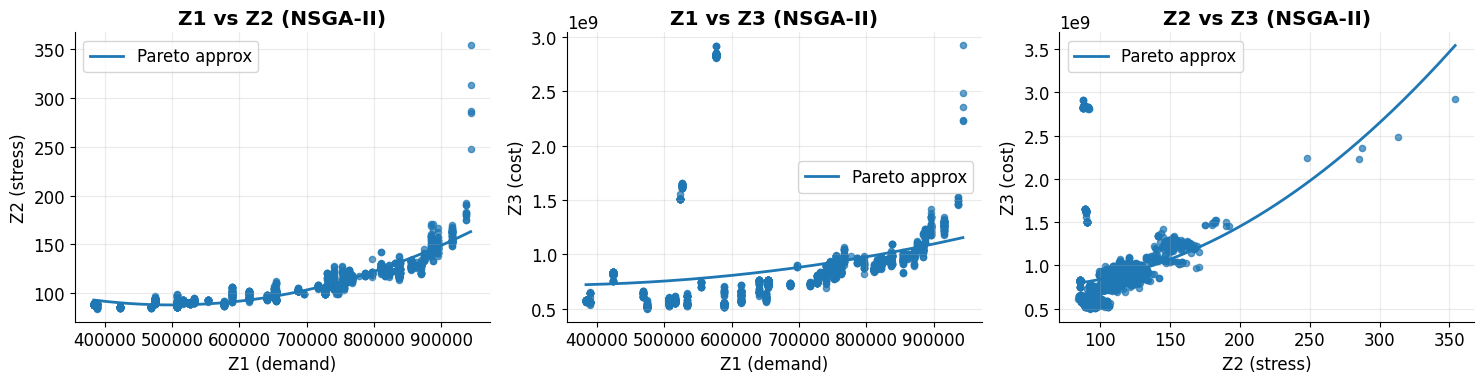

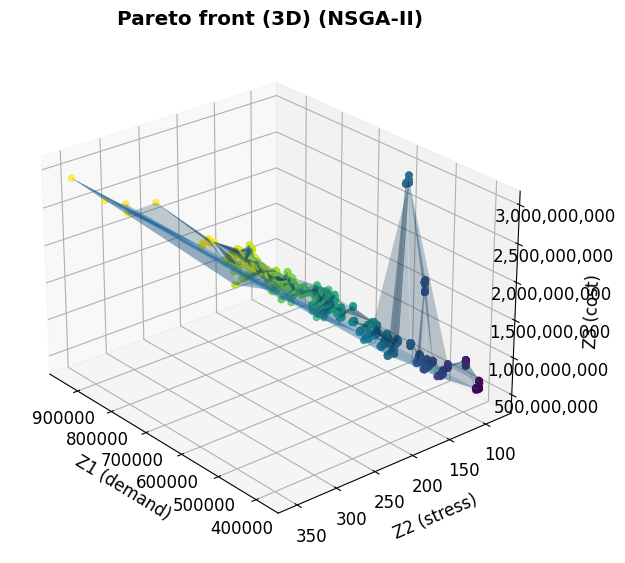

In [79]:
# ============================================================
# B) PLOTS —, but robust when Feasible=0
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.ticker import StrMethodFormatter

df_plot = df_nsga_deap.copy()
title_suffix = " (NSGA-II)"

df_plot = df_plot.dropna(subset=["Z1_demand","Z2_stress","Z3_cost","cv"]).copy()

if df_plot["ok"].sum() > 0:
    plot_df = df_plot[df_plot["ok"]].copy()
    print("Plotting feasible solutions:", len(plot_df))
else:
    # no feasible → plot the least-violating solutions
    K = min(200, len(df_plot))
    plot_df = df_plot.sort_values(["cv", "Z1_demand"], ascending=[True, False]).head(K).copy()
    print("Feasible=0 → plotting top", len(plot_df), "solutions with smallest cv")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

def _plot_with_fit(ax, x, y, xlabel, ylabel, title):
    ax.scatter(x, y, s=20, alpha=0.7)
    if len(x) >= 8:
        order = np.argsort(x)
        xs = np.asarray(x)[order]
        ys = np.asarray(y)[order]
        coeff = np.polyfit(xs, ys, deg=2)
        xs_fit = np.linspace(xs.min(), xs.max(), 200)
        ys_fit = np.polyval(coeff, xs_fit)
        ax.plot(xs_fit, ys_fit, linewidth=2, label="Pareto approx")
        ax.legend(loc="best")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

_plot_with_fit(axes[0], plot_df["Z1_demand"], plot_df["Z2_stress"],
               "Z1 (demand)", "Z2 (stress)", "Z1 vs Z2" + title_suffix)
_plot_with_fit(axes[1], plot_df["Z1_demand"], plot_df["Z3_cost"],
               "Z1 (demand)", "Z3 (cost)", "Z1 vs Z3" + title_suffix)
_plot_with_fit(axes[2], plot_df["Z2_stress"], plot_df["Z3_cost"],
               "Z2 (stress)", "Z3 (cost)", "Z2 vs Z3" + title_suffix)

plt.tight_layout()
plt.show()

# 3D
fig = plt.figure(figsize=(6.8, 5.8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(plot_df["Z1_demand"], plot_df["Z2_stress"], plot_df["Z3_cost"],
           s=20, alpha=0.7, c=plot_df["Z1_demand"])

if len(plot_df) >= 10:
    xs = plot_df["Z1_demand"].to_numpy()
    ys = plot_df["Z2_stress"].to_numpy()
    zs = plot_df["Z3_cost"].to_numpy()
    tri = mtri.Triangulation(xs, ys)
    ax.plot_trisurf(tri, zs, alpha=0.25, linewidth=0.2)

if len(plot_df):
    zmin = float(plot_df["Z3_cost"].min())
    zmax = float(plot_df["Z3_cost"].max())
    zpad = max(1.0, 0.08 * (zmax - zmin))
    ax.set_zlim(zmin - zpad, zmax + zpad)

ax.set_xlabel("Z1 (demand)", labelpad=8)
ax.set_ylabel("Z2 (stress)", labelpad=8)
ax.set_zlabel("Z3 (cost)", labelpad=10)
ax.zaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.tick_params(axis="z", pad=6)
ax.set_title("Pareto front (3D)" + title_suffix)
ax.view_init(elev=26, azim=140)
ax.set_box_aspect((1.2, 1.0, 0.8))
plt.tight_layout()
plt.show()


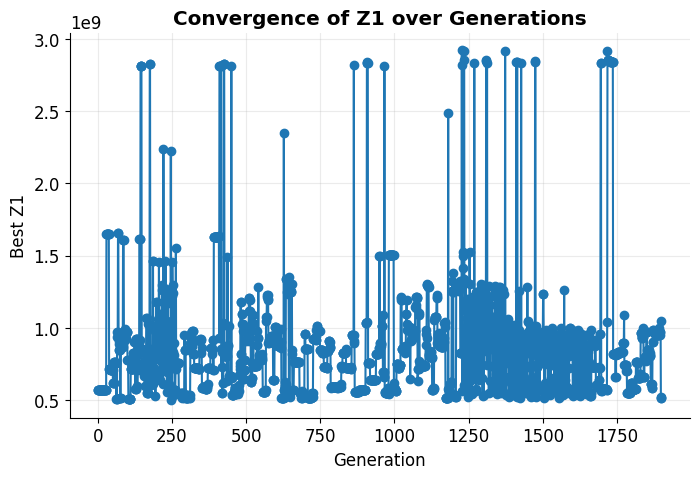

In [83]:
# Plot convergence of the algorithm after the iterations
import matplotlib.pyplot as plt

# Example: If you have a list of best fitness values per generation (e.g., from DEAP)
# Replace 'logbook' with your actual logbook or history object if available
# Here, we try to use Z1_best, Z2_best, Z3_best if they are tracked per generation

# If you have a logbook or history, use it. Otherwise, plot best values if available.
try:
    # If you have a DEAP logbook with 'min' or 'avg' values per generation
    gen = logbook.select('gen')
    fit_mins = logbook.chapters['fitness'].select('min')
    plt.figure(figsize=(8,5))
    plt.plot(gen, fit_mins, marker='o')
    plt.xlabel('Generation')
    plt.ylabel('Best Fitness (min)')
    plt.title('Convergence of the Algorithm')
    plt.grid(True)
    plt.show()
except Exception:
    # Fallback: Plot best Z1, Z2, Z3 if tracked per generation
    if 'zs' in globals():
        plt.figure(figsize=(8,5))
        plt.plot(zs, marker='o')
        plt.xlabel('Generation')
        plt.ylabel('Best Z1')
        plt.title('Convergence of Z1 over Generations')
        plt.grid(True)
        plt.show()
    else:
        print('No convergence data found. Please provide logbook/history or best values per generation.')

In [80]:
# ============================================================
# Routine: Plot optimization results (selected stations and links)
# ============================================================
import pyproj
import networkx as nx
import plotly.graph_objects as go

def plot_optimization_results(selected_stations, selected_links, G, candidates_with_station_gdf, solution_label):
    t2950 = pyproj.Transformer.from_crs("EPSG:2950", "EPSG:4326", always_xy=True)
    def to_latlon(x, y):
        lon, lat = t2950.transform(x, y)
        return [lat, lon]

    # Convert selected stations to lat/lon
    station_lats = []
    station_lons = []
    for xy in selected_stations:
        lat, lon = to_latlon(xy[0], xy[1])
        station_lats.append(lat)
        station_lons.append(lon)

    # Convert selected links to paths in lat/lon
    link_paths = []
    failed = 0
    for u, v in selected_links:
        try:
            path = nx.shortest_path(G, u, v, weight="length")
            coords = [to_latlon(x, y) for (x, y) in path]
            link_paths.append(coords)
        except Exception:
            failed += 1

    print("Failed shortest paths:", failed)

    # Center of the map
    cand_4326 = candidates_with_station_gdf.to_crs(epsg=4326)
    center = [cand_4326.geometry.y.mean(), cand_4326.geometry.x.mean()]

    # Create the figure
    fig = go.Figure()

    # Add links as lines
    for coords in link_paths:
        lats, lons = zip(*coords)
        fig.add_trace(go.Scattermapbox(
            lat=lats,
            lon=lons,
            mode='lines',
            line=dict(width=4, color='royalblue'),
            opacity=0.85,
            name='Selected link',
            hoverinfo='none'
        ))

    # Add stations as points
    fig.add_trace(go.Scattermapbox(
        lat=station_lats,
        lon=station_lons,
        mode='markers',
        marker=dict(size=14, color='limegreen', opacity=0.95),
        name='Selected station',
        text=[f"Selected: {xy}" for xy in selected_stations],
        hoverinfo='text'
    ))

    fig.update_layout(
        mapbox=dict(
            style="carto-positron",
            center=dict(lat=center[0], lon=center[1]),
            zoom=12
        ),
        legend=dict(x=0.01, y=0.01),
        margin=dict(l=0, r=0, t=40, b=0),
        title="Balanced/Best Solution on Montreal Basemap"
    )

    map_html = f"{solution_label}_nsga_balanced_solution_map.html"
    fig.write_html(map_html)
    print("Saved map:", map_html)

In [81]:
plot_optimization_results(selected_stations, selected_links, G, candidates_with_station_gdf, solution_label)

Failed shortest paths: 0
Saved map: best_nsga_balanced_solution_map.html


In [82]:
# ============================================================
# D) MAP — balanced/best solution on real Montreal basemap
# CRS: EPSG:2950 -> EPSG:4326 for Folium
# ============================================================

import folium
import pyproj
import networkx as nx
from folium import Element

t2950 = pyproj.Transformer.from_crs("EPSG:2950", "EPSG:4326", always_xy=True)

def to_latlon(x, y):
    lon, lat = t2950.transform(x, y)
    return [lat, lon]

# center from candidates
cand_4326 = candidates_with_station_gdf.to_crs(epsg=4326)
center = [cand_4326.geometry.y.mean(), cand_4326.geometry.x.mean()]

m = folium.Map(location=center, zoom_start=12, tiles="CartoDB positron")

# plot selected stations
for xy in selected_stations:
    folium.CircleMarker(
        location=to_latlon(xy[0], xy[1]),
        radius=8,
        color="black",
        weight=2,
        fill=True,
        fill_color="limegreen",
        fill_opacity=0.95,
        popup=f"Selected: {xy}"
    ).add_to(m)

# plot selected links as shortest paths
failed = 0
for u, v in selected_links:
    try:
        path = nx.shortest_path(G, u, v, weight="length")
        coords = [to_latlon(x, y) for (x, y) in path]
        folium.PolyLine(coords, color="royalblue", weight=5, opacity=0.85).add_to(m)
    except Exception:
        failed += 1

print("Failed shortest paths:", failed)

legend_html = f"""
<div style="position:fixed;bottom:50px;left:50px;width:270px;z-index:9999;font-size:15px;
background-color:rgba(255,255,255,0.92);border:2px solid grey;border-radius:8px;padding:10px;">
<b>Legend</b><br>
<span style="display:inline-block;width:18px;height:18px;background:limegreen;border-radius:50%;
margin-right:8px;border:2.5px solid black;"></span> Selected station<br>
<span style="display:inline-block;width:22px;height:6px;background:royalblue;margin-right:8px;"></span> Selected link<br>

</div>
"""
m.get_root().html.add_child(Element(legend_html))

display(m)
map_html = f"{solution_label}_nsga_balanced_solution_map.html"
m.save(map_html)
print("Saved map:", map_html)

Failed shortest paths: 0


Saved map: best_nsga_balanced_solution_map.html
